In [1]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
Resumen = pd.read_csv('Analisis GAC Full7agosto 2026(Resumen).csv', header=5)

In [3]:
#Ajustamos los nombres de las columnas
Resumen.columns = Resumen.columns.str.strip()

In [ ]:
#Registros mensuales
Resumen = Resumen.iloc[0:30].copy()

In [5]:
Resumen.head()

,Año,Mes,Leads,Efectivos,Ventas Reportadas,Obj Ventas,Ventas Real,% CAL,Obj Conversion,Conversion,...,Unnamed: 51,Unnamed: 52,Unnamed: 53,Unnamed: 54,Unnamed: 55,Proyeccion,Diferencia,Unnamed: 58,Unnamed: 59,Unnamed: 60
0,2024,Febrero,543,389,12.0,20.0,12.0,60%,3.5%,3.08%,...,NaN,NaN,ajuste sin marca,NaN,NaN,-,-,NaN,NaN,NaN
1,NaN,Marzo,178,128,7.0,20.0,7.0,35%,3.5%,5.47%,...,NaN,Marca,38%,51%,65.000000,-,-,NaN,NaN,NaN
2,NaN,Abril,416,288,8.0,20.0,8.0,40%,3.5%,2.78%,...,743.548087,1212,22,NaN,1440.540073,-,-,NaN,Crédito,Contado
3,NaN,Mayo,422,274,13.0,20.0,13.0,65%,3.5%,4.74%,...,NaN,601.8679177,13,NaN,NaN,-,-,NaN,77.55%,20.29%
4,NaN,Junio,967,620,6.0,20.0,6.0,30%,3.5%,0.97%,...,NaN,180,4,NaN,25.723930,-,-,NaN,NaN,NaN


In [6]:
Resumen.tail()

,Año,Mes,Leads,Efectivos,Ventas Reportadas,Obj Ventas,Ventas Real,% CAL,Obj Conversion,Conversion,...,Unnamed: 51,Unnamed: 52,Unnamed: 53,Unnamed: 54,Unnamed: 55,Proyeccion,Diferencia,Unnamed: 58,Unnamed: 59,Unnamed: 60
25,NaN,Marzo,"1,785",944,38.0,40.0,41.0,103%,4.5%,4.34%,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26,NaN,Abril,"1,393",724,39.0,40.0,41.0,103%,4.5%,5.66%,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,NaN,Mayo,"1,251",736,35.0,40.0,35.0,88%,4.5%,4.76%,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28,NaN,Junio,"1,315",754,37.0,40.0,37.0,93%,4.5%,4.91%,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29,NaN,Julio,520,282,33.0,40.0,33.0,83%,4.5%,11.70%,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
Resumen.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 61 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Año                           3 non-null      str    
 1   Mes                           30 non-null     str    
 2   Leads                         30 non-null     str    
 3   Efectivos                     30 non-null     str    
 4   Ventas Reportadas             30 non-null     float64
 5   Obj Ventas                    30 non-null     float64
 6   Ventas Real                   30 non-null     float64
 7   % CAL                         30 non-null     str    
 8   Obj Conversion                30 non-null     str    
 9   Conversion                    30 non-null     str    
 10  % CAL                         30 non-null     str    
 11  Obj UN                        7 non-null      str    
 12  UN                            6 non-null      str    
 13  %  CAL            

In [8]:
#Convertimos las variables seleccionadas a valores numéricos
Resumen['Leads'] = pd.to_numeric(Resumen['Leads'].astype(str).str.replace(',', ''), errors='coerce')

Resumen['Efectivos'] = pd.to_numeric(Resumen['Efectivos'].astype(str).str.replace(',', ''), errors='coerce')

Resumen['Ventas Real'] = pd.to_numeric(Resumen['Ventas Real'], errors='coerce')

Resumen['Conversion'] = pd.to_numeric(Resumen['Conversion'].astype(str).str.replace('%', ''), errors='coerce')

Resumen['SDC'] = pd.to_numeric(Resumen['SDC'], errors='coerce')

Resumen['Autorizadas'] = pd.to_numeric(Resumen['Autorizadas'], errors='coerce')

Resumen['Formalizado'] = pd.to_numeric(Resumen['Formalizado'], errors='coerce')

Resumen['Credito'] = pd.to_numeric(Resumen['Credito'], errors='coerce')

Resumen['PDM'] = pd.to_numeric(Resumen['PDM'], errors='coerce')

Resumen['Lead / Venta'] = pd.to_numeric(Resumen['Lead / Venta'], errors='coerce')

In [ ]:
#Calculamos el numero total de la población "n"
Resumen['Ventas Real'].info()
n=30

#Obtenemos limites
Max=Resumen['Ventas Real'].max()
Min=Resumen['Ventas Real'].min()
Limites= [Min, Max]
Limites

<class 'pandas.Series'>
RangeIndex: 30 entries, 0 to 29
Series name: Ventas Real
Non-Null Count  Dtype  
--------------  -----  
30 non-null     float64
dtypes: float64(1)
memory usage: 372.0 bytes


[np.float64(6.0), np.float64(42.0)]

In [10]:
#Calculamos el rango R
R=Max-Min
R

np.float64(36.0)

In [ ]:
ni= 1+3.32*np.log10(n)
ni

np.float64(5.904042565669279)

In [ ]:
i=R/ni
i

np.float64(6.097517014753951)

In [ ]:

intervalos=np.linspace(Min, Max, 7)
intervalos

array([ 6., 12., 18., 24., 30., 36., 42.])

In [ ]:


categorias= ["6-12", 
             "12-18",
             "18-24", 
             "24-30",
             "30-36", 
             "36-42"]

In [ ]:
#categorías en la columna numérica
Resumen['Ventas Real']=pd.cut(x=Resumen['Ventas Real'], bins=intervalos, labels=categorias, include_lowest=True)
Resumen['Ventas Real']

0      6-12
1      6-12
2      6-12
3     12-18
4      6-12
5     18-24
6     12-18
7     12-18
8     18-24
9     18-24
10    30-36
11    24-30
12    18-24
13    24-30
14    24-30
15    30-36
16    36-42
17    30-36
18    24-30
19    36-42
20    36-42
21    36-42
22    30-36
23    36-42
24    24-30
25    36-42
26    36-42
27    30-36
28    36-42
29    30-36
Name: Ventas Real, dtype: category
Categories (6, str): ['6-12' < '12-18' < '18-24' < '24-30' < '30-36' < '36-42']

In [ ]:
Tabla_freq = Resumen['Ventas Real'].value_counts(sort=False).reset_index()
Tabla_freq

,Ventas Real,count
0,6-12,4
1,12-18,3
2,18-24,4
3,24-30,5
4,30-36,6
5,36-42,8


In [ ]:
Filtro= Tabla_freq[Tabla_freq['count']>0]
Filtro

,Ventas Real,count
0,6-12,4
1,12-18,3
2,18-24,4
3,24-30,5
4,30-36,6
5,36-42,8


In [ ]:
Filtro_index= Filtro.set_index('Ventas Real')
Filtro_index

,count
Ventas Real,
6-12,4
12-18,3
18-24,4
24-30,5
30-36,6
36-42,8


Text(0, 0.5, 'Frecuencia')

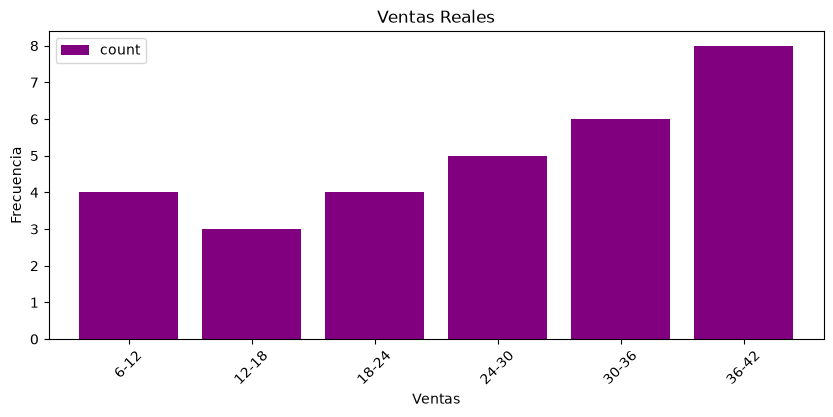

In [ ]:
Filtro_index.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "purple", rot=45)
plt.title('Ventas Reales')
plt.xlabel('Ventas')
plt.ylabel('Frecuencia')

In [21]:
Resumen['Obj Ventas'].info()
n=30

Max=Resumen['Obj Ventas'].max()
Min=Resumen['Obj Ventas'].min()
Limites= [Min, Max]
Limites

<class 'pandas.Series'>
RangeIndex: 30 entries, 0 to 29
Series name: Obj Ventas
Non-Null Count  Dtype  
--------------  -----  
30 non-null     float64
dtypes: float64(1)
memory usage: 372.0 bytes


[np.float64(20.0), np.float64(40.0)]

In [22]:
R=Max-Min
R

np.float64(20.0)

In [23]:
ni= 1+3.32*np.log10(n)
ni

np.float64(5.904042565669279)

In [24]:
i=R/ni
i

np.float64(3.387509452641084)

In [25]:
intervalos=np.linspace(20, 40, 7)
intervalos

array([20.        , 23.33333333, 26.66666667, 30.        , 33.33333333,
       36.66666667, 40.        ])

In [26]:
categorias= ["20-23.33",
             "23.33-26.67",
             "26.67-30",
             "30-33.33",
             "33.33-36.67",
             "36.67-40"]

In [27]:
Resumen['Obj Ventas']=pd.cut(x=Resumen['Obj Ventas'], bins=intervalos, labels=categorias, include_lowest=True)
Resumen['Obj Ventas']

0        20-23.33
1        20-23.33
2        20-23.33
3        20-23.33
4        20-23.33
5        20-23.33
6        20-23.33
7        20-23.33
8        20-23.33
9     23.33-26.67
10       26.67-30
11       26.67-30
12    23.33-26.67
13    23.33-26.67
14       26.67-30
15       26.67-30
16    33.33-36.67
17    33.33-36.67
18    33.33-36.67
19       36.67-40
20       36.67-40
21       36.67-40
22       36.67-40
23       36.67-40
24       36.67-40
25       36.67-40
26       36.67-40
27       36.67-40
28       36.67-40
29       36.67-40
Name: Obj Ventas, dtype: category
Categories (6, str): ['20-23.33' < '23.33-26.67' < '26.67-30' < '30-33.33' < '33.33-36.67' < '36.67-40']

In [28]:
Tabla_freq = Resumen['Obj Ventas'].value_counts(sort=False).reset_index()
Tabla_freq

,Obj Ventas,count
0,20-23.33,9
1,23.33-26.67,3
2,26.67-30,4
3,30-33.33,0
4,33.33-36.67,3
5,36.67-40,11


In [29]:
Filtro= Tabla_freq[Tabla_freq['count']>0]
Filtro

,Obj Ventas,count
0,20-23.33,9
1,23.33-26.67,3
2,26.67-30,4
4,33.33-36.67,3
5,36.67-40,11


In [30]:
Filtro_index= Filtro.set_index('Obj Ventas')
Filtro_index

,count
Obj Ventas,
20-23.33,9
23.33-26.67,3
26.67-30,4
33.33-36.67,3
36.67-40,11


Text(0, 0.5, 'Frecuencia')

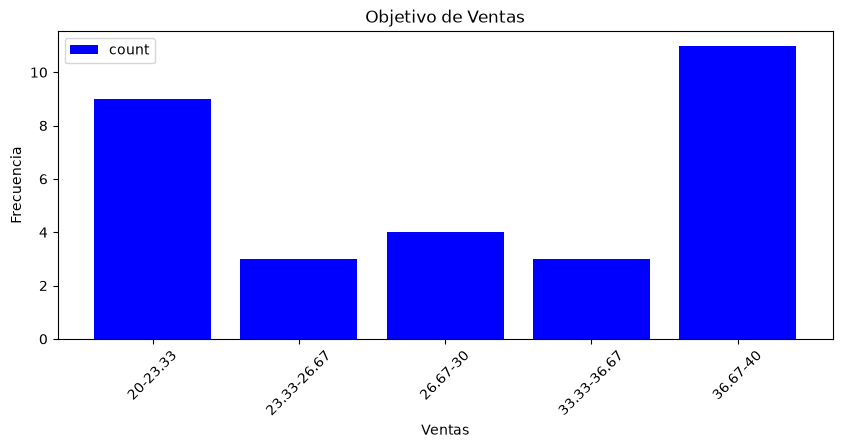

In [31]:
Filtro_index.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "blue", rot=45)
plt.title('Objetivo de Ventas')
plt.xlabel('Ventas')
plt.ylabel('Frecuencia')

In [32]:
intervalos=np.linspace(1, 25, 7)
intervalos

array([ 1.,  5.,  9., 13., 17., 21., 25.])

In [33]:
categorias= ["1-5 formalizados",
             "5-9 formalizados",
             "9-13 formalizados",
             "13-17 formalizados",
             "17-21 formalizados",
             "21-25 formalizados"]

Text(0, 0.5, 'Frecuencia')

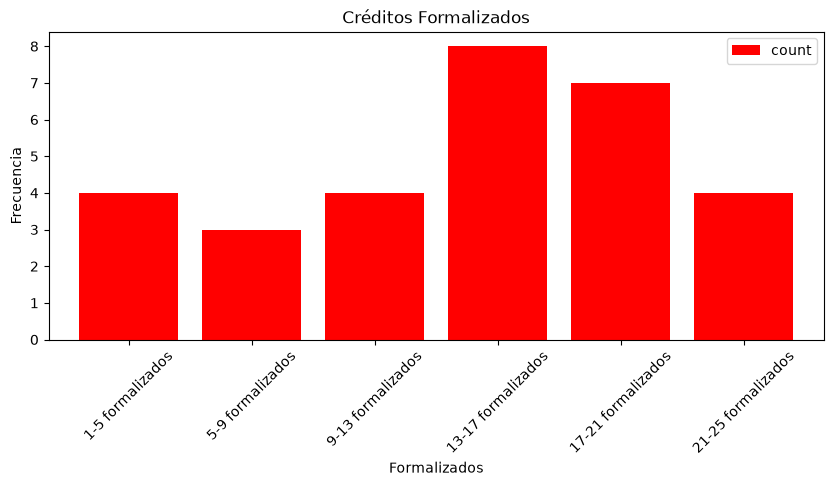

In [34]:
Resumen['Formalizado']=pd.cut(x=Resumen['Formalizado'], bins=intervalos, labels=categorias, include_lowest=True)

Tabla_freq = Resumen['Formalizado'].value_counts(sort=False).reset_index()
Filtro= Tabla_freq[Tabla_freq['count']>0]
Filtro_index= Filtro.set_index('Formalizado')

Filtro_index.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "red", rot=45)
plt.title('Créditos Formalizados')
plt.xlabel('Formalizados')
plt.ylabel('Frecuencia')